# Menota-_Stjórn_ Topic Analysis

This notebook will generate a complete term list for Menota and _Stjórn_, but right now I'm still just paring down the code duplicated from the stylometry notebook.

In [1]:
import os,glob,json
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gensim import corpora
from gensim.models import LdaModel,CoherenceModel

def set_xmargin(ax, left=0.0, right=0.3):
    ax.set_xmargin(0)
    ax.autoscale_view()
    lim = ax.get_xlim()
    delta = np.diff(lim)
    left = lim[0] - delta*left
    right = lim[1] + delta*right
    ax.set_xlim(left,right)

def normalize(target):
    # This dict limits orthographical variation beyond the rule sets
    # of stjorn-extract.ipynb and menota-extract.ipynb:
    matrix = {
        'j': 'i',
        'v': 'u',
        '': 'u', # &vacute;
        # Experiment with *either* normalizing ð to þ,
        # or else both to d (because AM 226 often uses d for ð):
        'ð': 'þ',
        #'ð': 'd',
        #'þ': 'd',
        'á': 'a',
        'ǽ': 'æ',
        'ę': 'æ',
        'é': 'e',
        'í': 'i',
        'ó': 'o',
        '': 'ǫ', # &oogonacute;
        'ú': 'u',
        'ý': 'y',
        'ǿ': 'ø',
        'k': 'c', # rather than vice versa, because of Latin (e.g. Lucifer)
        '[': '',
        ']': '',
        '%': '',
        '(': '',
        ')': '',
        '+': '',
        '/': '',
        '*aenl;': 'a',
        ':': '',
        ';': '',
        '<': '',
        '>': '',
        '?': '',
        '`': '',
        '´': '',
        '"': ''
        }
    for k,v in matrix.items():
        target = target.replace(k, v)
    return target


In [2]:
chunk_size = 2000

In [3]:
with open('token_indices.json') as index_file:
    token_indices = json.load(index_file)

titles = ['prologue', 'introduction', 'gn', 'ex', 'lv', 'nm', 'dt', 'ios', 'idc', 'rt', '1sm', '2sm', '3rg', '4rg']
work_indices = {
    'stjorn1': 650,
    'stjorn2': 124417,
    'stjorn3a': 147678,
    'stjorn4': 156943,
    'stjorn3b': 160719
}

tokens = []
for title in titles:
    with open(f"nlp/{title}.txt") as raw:
        document = normalize(raw.read().replace('\n', ' '))
        tokens.extend(document.split())

len(tokens)

271197

In [4]:
corpus = dict()
corpus['stj1'] = tokens[work_indices['stjorn1']:work_indices['stjorn2']]
corpus['stj2'] = tokens[work_indices['stjorn2']:work_indices['stjorn3a']]
corpus['stj3'] = tokens[work_indices['stjorn3a']:work_indices['stjorn4']] + tokens[work_indices['stjorn3b']:]
corpus['stj4'] = tokens[work_indices['stjorn4']:work_indices['stjorn3b']]

In [5]:
for text in glob.glob('../menota/dipl/*txt'):
    ref = os.path.basename(text).replace('.txt', '')
    with open(text) as doc:
        corpus[ref] = normalize(doc.read().replace('\n', '')).split()

In [6]:
terms = sorted(list(set([token for document in list(corpus.values()) for token in document])))

In [7]:
with open('all_terms.json', 'w', encoding='utf-8') as f:
    json.dump(terms, f, ensure_ascii=False, indent=4)

In [8]:
dictionary = corpora.Dictionary(corpus.values())
dictionary.filter_extremes(no_below=10, no_above=0.15)
dtmatrix = [dictionary.doc2bow(doc) for doc in corpus.values()]

In [9]:
num_topics = range(1,18)
num_keywords = 15

LDA_models = {}
LDA_topics = {}
for i in num_topics:
    LDA_models[i] = LdaModel(corpus=dtmatrix,
                             id2word=dictionary,
                             num_topics=i,
                             update_every=1,
                             chunksize=len(dtmatrix),
                             passes=20,
                             alpha='auto',
                             random_state=42)

    shown_topics = LDA_models[i].show_topics(num_topics=i, 
                                             num_words=num_keywords,
                                             formatted=False)
    LDA_topics[i] = [[word[0] for word in topic[1]] for topic in shown_topics]

In [10]:
def jaccard_similarity(topic_1, topic_2):
    """
    Derives the Jaccard similarity of two topics

    Jaccard similarity:
    - A statistic used for comparing the similarity and diversity of sample sets
    - J(A,B) = (A ∩ B)/(A ∪ B)
    - Goal is low Jaccard scores for coverage of the diverse elements
    """
    intersection = set(topic_1).intersection(set(topic_2))
    union = set(topic_1).union(set(topic_2))
                    
    return float(len(intersection))/float(len(union))

In [11]:
LDA_stability = {}
for i in range(0, len(num_topics)-1):
    jaccard_sims = []
    for t1, topic1 in enumerate(LDA_topics[num_topics[i]]): # pylint: disable=unused-variable
        sims = []
        for t2, topic2 in enumerate(LDA_topics[num_topics[i+1]]): # pylint: disable=unused-variable
            sims.append(jaccard_similarity(topic1, topic2))    
        
        jaccard_sims.append(sims)    
    
    LDA_stability[num_topics[i]] = jaccard_sims
                
mean_stabilities = [np.array(LDA_stability[i]).mean() for i in num_topics[:-1]]

In [12]:
coherences = [CoherenceModel(model=LDA_models[i], texts=corpus.values(), dictionary=dictionary, coherence='c_v').get_coherence()\
              for i in num_topics[:-1]]

In [13]:
coh_sta_diffs = [coherences[i] - mean_stabilities[i] for i in range(num_keywords)[:-1]] # limit topic numbers to the number of keywords
coh_sta_max = max(coh_sta_diffs)
coh_sta_max_idxs = [i for i, j in enumerate(coh_sta_diffs) if j == coh_sta_max]
ideal_topic_num_index = coh_sta_max_idxs[0] # choose fewer topics in case there's more than one max
ideal_topic_num = num_topics[ideal_topic_num_index]

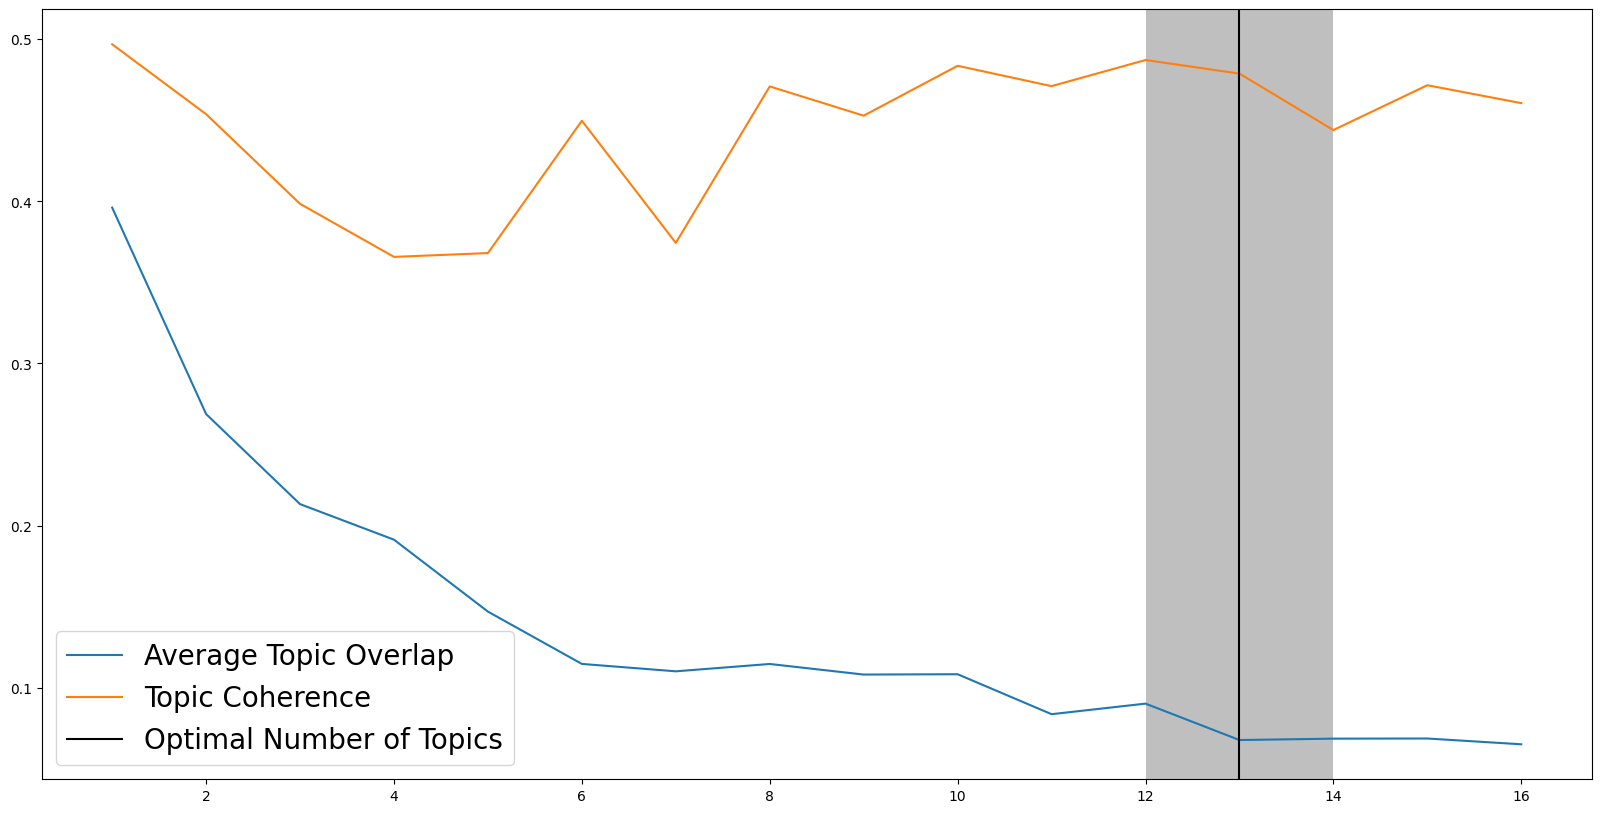

In [14]:
plt.figure(figsize=(20,10))
ax = plt.plot(pd.DataFrame(num_topics[:-1]).values, pd.DataFrame(mean_stabilities).values, label='Average Topic Overlap')
ax = plt.plot(pd.DataFrame(num_topics[:-1]).values, pd.DataFrame(coherences).values, label='Topic Coherence')

plt.axvline(x=ideal_topic_num, label='Optimal Number of Topics', color='black')
plt.axvspan(xmin=ideal_topic_num - 1, xmax=ideal_topic_num + 1, alpha=0.5, facecolor='grey')

plt.legend(fontsize=20)
plt.show()